In [1]:
import radiate as rd
import polars as pl

rd.random.seed(67123)


In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])


In [3]:
target_species = 4.0
rolling = int(target_species)

spec_count_signal = rd.metric("count.species").rolling(rolling).mean() / target_species
spec_dist_signal = (
    rd.metric("species.distance").mean().rolling(rolling).mean() / target_species
)
spec_thresh_signal = rd.metric("species.threshold").rolling(rolling).mean()
spec_evenness_signal = rd.metric("species.evenness").rolling(rolling).mean()

distance_signal = (
    (rd.lit(0.9) * spec_count_signal)
    + (rd.lit(0.4) * spec_dist_signal)
    + (rd.lit(0.2) * spec_thresh_signal)
    + (rd.lit(0.1) * spec_evenness_signal)
).clamp(0.01, 10.0)


# distance_signal.__repr__()


In [ ]:
collector = rd.MetricCollector()


engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(rd.NeatDistance(), distance_signal)
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)


2026-04-14T04:21:33.963221Z  INFO Epoch 1    | Score:   2.0038 | Time: 290.21µs
2026-04-14T04:21:33.963377Z  INFO Epoch 2    | Score:   2.0038 | Time: 398.46µs
2026-04-14T04:21:33.963552Z  INFO Epoch 3    | Score:   1.6821 | Time: 517.33µs
2026-04-14T04:21:33.963744Z  INFO Epoch 4    | Score:   1.6821 | Time: 646.33µs
2026-04-14T04:21:33.963977Z  INFO Epoch 5    | Score:   1.6821 | Time: 816.71µs
2026-04-14T04:21:33.964223Z  INFO Epoch 6    | Score:   1.6821 | Time: 993.25µs
2026-04-14T04:21:33.964444Z  INFO Epoch 7    | Score:   1.6821 | Time: 1.15ms
2026-04-14T04:21:33.964639Z  INFO Epoch 8    | Score:   1.6821 | Time: 1.29ms
2026-04-14T04:21:33.964828Z  INFO Epoch 9    | Score:   1.6820 | Time: 1.42ms
2026-04-14T04:21:33.965053Z  INFO Epoch 10   | Score:   1.6820 | Time: 1.58ms
2026-04-14T04:21:33.965364Z  INFO Epoch 11   | Score:   1.6820 | Time: 1.79ms
2026-04-14T04:21:33.965601Z  INFO Epoch 12   | Score:   1.6820 | Time: 1.95ms
2026-04-14T04:21:33.965819Z  INFO Epoch 13   | Score

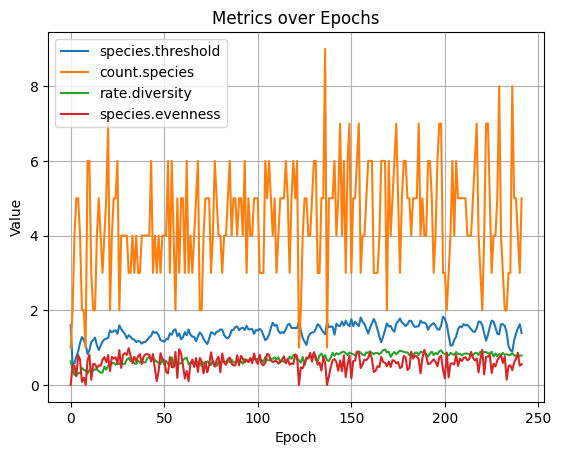

In [5]:
collector.plot(
    "species.threshold", "count.species", "rate.diversity", "species.evenness"
)


In [6]:
df = collector.to_polars()
df.filter(pl.col("name") == "count.species")

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.species""",1.0,1.0,1.0,0.0,0.0,NaN,1.0,1.0,1,null,null,null,null,null,null,0,1,"[""species"", ""statistic""]"
"""count.species""",2.0,3.0,1.5,0.707107,0.5,NaN,1.0,2.0,2,null,null,null,null,null,null,1,1,"[""species"", ""statistic""]"
"""count.species""",4.0,7.0,2.333333,1.527525,2.333333,8.049846,1.0,4.0,3,null,null,null,null,null,null,2,1,"[""species"", ""statistic""]"
"""count.species""",5.0,12.0,3.0,1.825742,3.333333,4.3260e-7,1.0,5.0,4,null,null,null,null,null,null,3,1,"[""species"", ""statistic""]"
"""count.species""",5.0,17.0,3.4,1.81659,3.3,-1.618874,1.0,5.0,5,null,null,null,null,null,null,4,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""count.species""",5.0,1052.0,4.420168,1.408209,1.983051,0.132344,1.0,9.0,238,null,null,null,null,null,null,237,1,"[""species"", ""statistic""]"
"""count.species""",5.0,1057.0,4.422594,1.405748,1.976126,0.118822,1.0,9.0,239,null,null,null,null,null,null,238,1,"[""species"", ""statistic""]"
"""count.species""",4.0,1061.0,4.420833,1.403069,1.968602,0.130505,1.0,9.0,240,null,null,null,null,null,null,239,1,"[""species"", ""statistic""]"
